In [2]:
# Run once per kernel session
%pip install opencv-python scikit-image PyWavelets

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import skimage
import pywt
print('cv2 OK:', cv2.__version__)
print('skimage OK:', skimage.__version__)
print('pywt OK:', pywt.__version__)

ModuleNotFoundError: No module named 'cv2'

### 01 Apply different noise types (Gaussian, Salt & Pepper) to an image and use the following filters to remove noise:
i)	Mean Filter

ii)	Gaussian Filter
Compare the effectiveness of each method. Which filter works best for which type of noise?


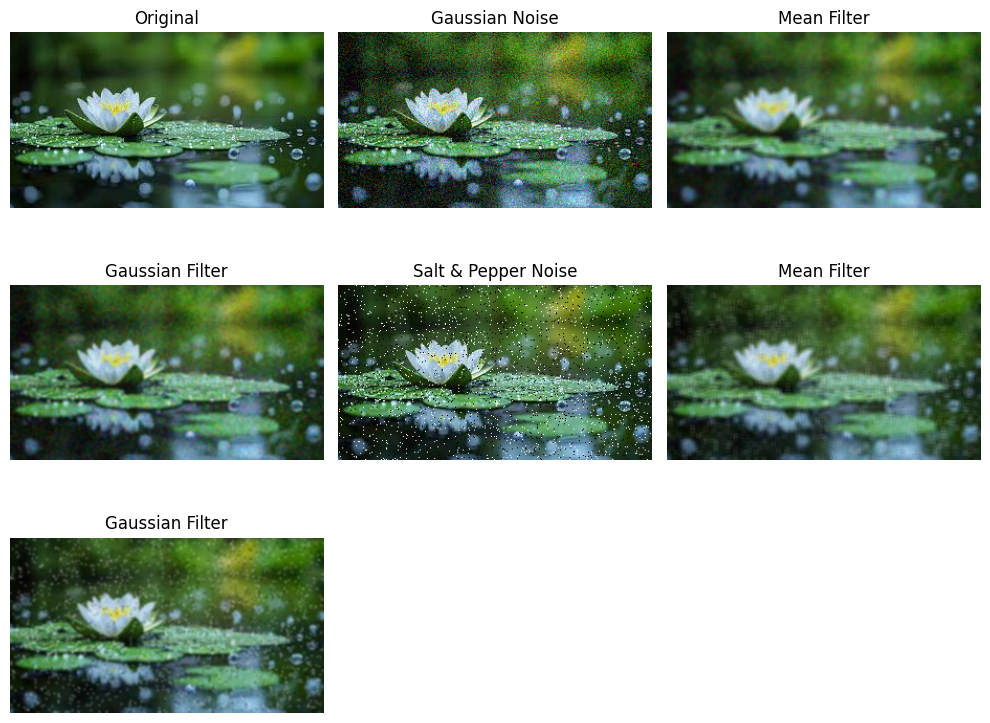

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Load Image ----------------
# Read image from file
img = cv2.imread('download.jpg')

# Convert BGR (OpenCV default) to RGB (for matplotlib display)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ---------------- Gaussian Noise Function ----------------
def add_gaussian_noise(image):
    # Generate Gaussian noise (mean=0, std=25)
    noise = np.random.normal(0, 25, image.shape)
    
    # Add noise to original image
    noisy = image + noise
    
    # Clip values to valid range (0–255) and convert to uint8
    return np.clip(noisy, 0, 255).astype(np.uint8)


# ---------------- Salt & Pepper Noise Function ----------------
def add_sp_noise(image):
    # Copy original image
    noisy = image.copy()
    
    # Probability of noise
    prob = 0.02

    # -------- Add Salt (white pixels) --------
    num_salt = int(prob * image.size / 2)
    
    # Random coordinates
    x = np.random.randint(0, image.shape[0], num_salt)
    y = np.random.randint(0, image.shape[1], num_salt)
    
    # Set selected pixels to white (255)
    noisy[x, y] = 255

    # -------- Add Pepper (black pixels) --------
    num_pepper = int(prob * image.size / 2)
    
    # Random coordinates
    x = np.random.randint(0, image.shape[0], num_pepper)
    y = np.random.randint(0, image.shape[1], num_pepper)
    
    # Set selected pixels to black (0)
    noisy[x, y] = 0

    return noisy


# ---------------- Add Noise to Image ----------------
# Apply Gaussian noise
gaussian_noisy = add_gaussian_noise(img)

# Apply Salt & Pepper noise
sp_noisy = add_sp_noise(img)


# ---------------- Apply Filters ----------------
# Mean filter (average filter)
mean_gaussian = cv2.blur(gaussian_noisy, (5,5))   # For Gaussian noise
mean_sp = cv2.blur(sp_noisy, (5,5))               # For S&P noise

# Gaussian filter (weighted smoothing)
gauss_gaussian = cv2.GaussianBlur(gaussian_noisy, (5,5), 0)
gauss_sp = cv2.GaussianBlur(sp_noisy, (5,5), 0)


# ---------------- Display Results ----------------
# Titles for each image
titles = [
    'Original', 'Gaussian Noise', 'Mean Filter', 'Gaussian Filter',
    'Salt & Pepper Noise', 'Mean Filter', 'Gaussian Filter'
]

# List of images to display
images = [
    img, gaussian_noisy, mean_gaussian, gauss_gaussian,
    sp_noisy, mean_sp, gauss_sp
]

# Create figure
plt.figure(figsize=(10,8))

# Loop through images and display in grid
for i in range(len(images)):
    plt.subplot(3,3,i+1)     # 3x3 grid
    plt.imshow(images[i])    # Show image
    plt.title(titles[i])     # Set title
    plt.axis('off')          # Hide axis

# Adjust layout and display
plt.tight_layout()
plt.show()

### lab 02: Perform histogram equalization on a low-contrast image.
### i)	Compare the histogram before and after equalization.

### ii)	How does histogram equalization affect image brightness and contrast?


C:\Users\User\AppData\Local\Temp\ipykernel_19048\2736345119.py:27: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(), 256, [0,256])
C:\Users\User\AppData\Local\Temp\ipykernel_19048\2736345119.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized.ravel(), 256, [0,256])


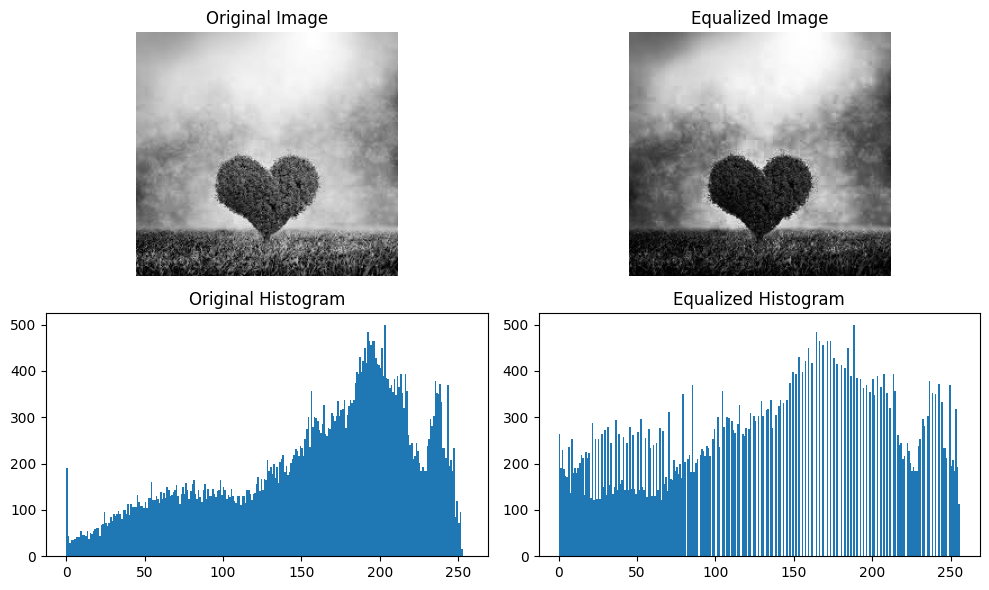

In [ ]:
import cv2
import matplotlib.pyplot as plt

# ---------------- Load Image ----------------
# Load image in grayscale mode (0 = grayscale)
img = cv2.imread('images.jpg', 0)


# ---------------- Histogram Equalization ----------------
# Apply histogram equalization to improve contrast
equalized = cv2.equalizeHist(img)


# ---------------- Plot Results ----------------
# Create a figure window
plt.figure(figsize=(10,6))

# -------- Original Image --------
plt.subplot(2,2,1)              # 2x2 grid, position 1
plt.imshow(img, cmap='gray')   # Display grayscale image
plt.title('Original Image')
plt.axis('off')                # Hide axis

# -------- Equalized Image --------
plt.subplot(2,2,2)             
plt.imshow(equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

# -------- Original Histogram --------
plt.subplot(2,2,3)
# ravel() converts image into 1D array for histogram
plt.hist(img.ravel(), 256, [0,256])
plt.title('Original Histogram')

# -------- Equalized Histogram --------
plt.subplot(2,2,4)
plt.hist(equalized.ravel(), 256, [0,256])
plt.title('Equalized Histogram')

# Adjust layout for better spacing
plt.tight_layout()

# Display all plots
plt.show()

### Lab3: Segment an object from an image using different thresholding techniques:
### i)	Global Thresholding (Otsu’s method)
### ii)	Adaptive Thresholding
### iii)	Compare results and discuss when adaptive thresholding is preferable over global 

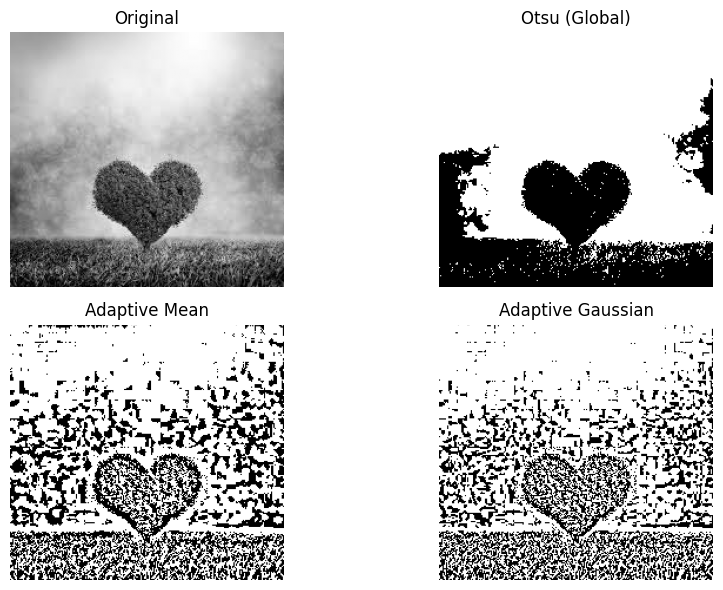

In [ ]:
import cv2
import matplotlib.pyplot as plt

# ---------------- Load Image ----------------
# Read image in grayscale mode (0 = grayscale)
img = cv2.imread('images.jpg', 0)


# ---------------- 1. Global Thresholding (Otsu) ----------------
# Apply Otsu's method to automatically find optimal threshold
# THRESH_BINARY → convert image to binary (0 or 255)
_, otsu = cv2.threshold(img, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# ---------------- 2. Adaptive Thresholding ----------------

# -------- Adaptive Mean Thresholding --------
# Threshold is calculated as mean of neighborhood pixels
adaptive_mean = cv2.adaptiveThreshold(img, 255,
                                      cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY,
                                      11, 2)  # 11 = block size, 2 = constant


# -------- Adaptive Gaussian Thresholding --------
# Threshold is calculated using weighted (Gaussian) mean
adaptive_gaussian = cv2.adaptiveThreshold(img, 255,
                                          cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY,
                                          11, 2)


# ---------------- Display Results ----------------

# Titles for each image
titles = ['Original', 'Otsu (Global)', 
          'Adaptive Mean', 'Adaptive Gaussian']

# Store images in list
images = [img, otsu, adaptive_mean, adaptive_gaussian]

# Create figure window
plt.figure(figsize=(10,6))

# Loop to display images in 2x2 grid
for i in range(4):
    plt.subplot(2,2,i+1)          # 2 rows, 2 columns
    plt.imshow(images[i], cmap='gray')  # Show grayscale image
    plt.title(titles[i])          # Set title
    plt.axis('off')               # Hide axis

# Adjust layout
plt.tight_layout()

# Show all images
plt.show()

### Lab : 04 Load a grayscale image and apply the following edge detection techniques: 
### i)	Sobel Operator
### ii)	Prewitt Operator
### iii)	Canny Edge Detector
### Compare the results by analyzing the sharpness and completeness of detected edges


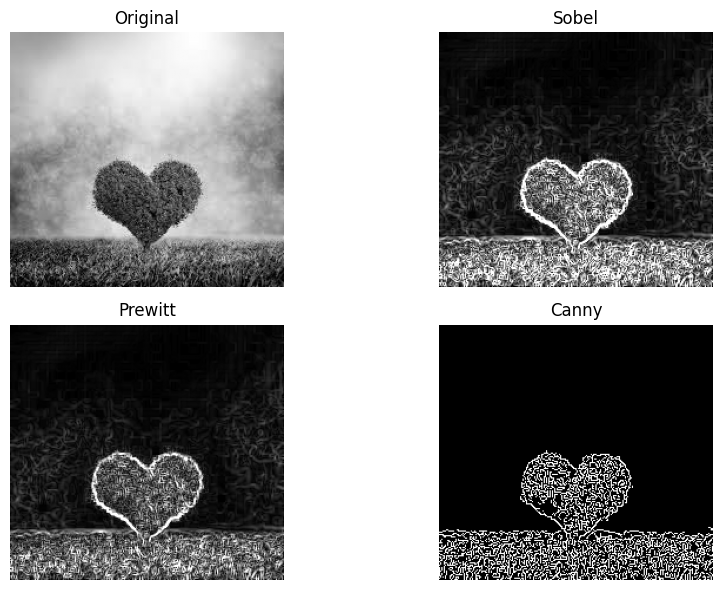

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Load Image ----------------
# Read image in grayscale mode
img = cv2.imread('images.jpg', 0)


# ---------------- Sobel Edge Detection ----------------
# Compute gradient in x-direction (horizontal edges)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

# Compute gradient in y-direction (vertical edges)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Combine gradients to get edge magnitude
sobel = cv2.magnitude(sobelx, sobely)

# Convert to 8-bit image (0–255 range)
sobel = np.uint8(np.clip(sobel, 0, 255))


# ---------------- Prewitt Edge Detection ----------------
# Define Prewitt kernels for x and y directions
kernelx = np.array([[-1, 0, 1],
                    [-1, 0, 1],
                    [-1, 0, 1]])

kernely = np.array([[-1, -1, -1],
                    [ 0,  0,  0],
                    [ 1,  1,  1]])

# Apply convolution using filter2D
prewittx = cv2.filter2D(img, cv2.CV_64F, kernelx)
prewitty = cv2.filter2D(img, cv2.CV_64F, kernely)

# Combine x and y gradients
prewitt = np.sqrt(prewittx**2 + prewitty**2)

# Convert to 8-bit image
prewitt = np.uint8(np.clip(prewitt, 0, 255))


# ---------------- Canny Edge Detection ----------------
# Apply Canny algorithm with lower and upper thresholds
canny = cv2.Canny(img, 100, 200)


# ---------------- Display Results ----------------
# Titles for each image
titles = ['Original', 'Sobel', 'Prewitt', 'Canny']

# Store images in list
images = [img, sobel, prewitt, canny]

# Create figure
plt.figure(figsize=(10,6))

# Display images in 2x2 grid
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')  # Show grayscale image
    plt.title(titles[i])                # Set title
    plt.axis('off')                     # Hide axis

# Adjust layout
plt.tight_layout()

# Show all images
plt.show()

### Lab: 05 Write a Python program to Character Segment of an image.

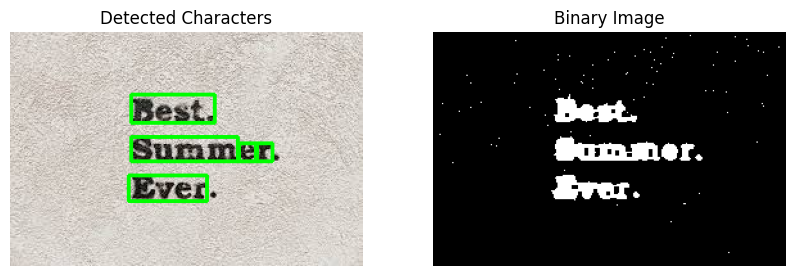

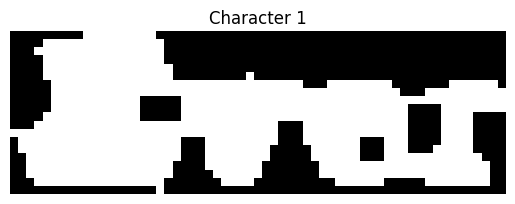

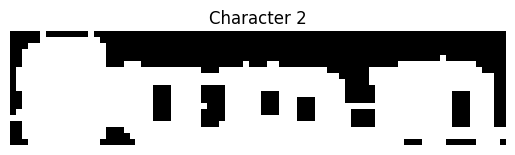

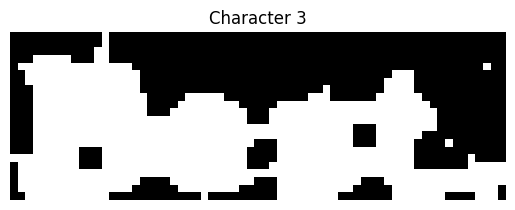

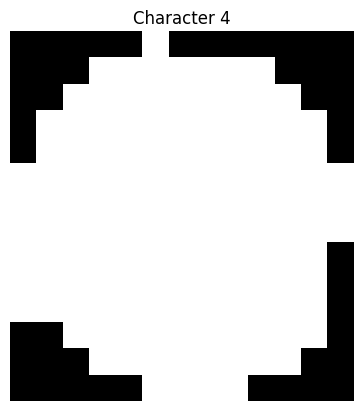

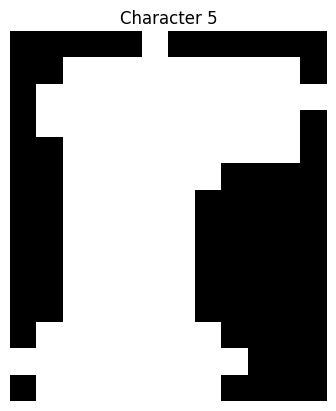

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('text.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

# Noise removal (optional)
kernel = np.ones((3,3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours left to right
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

# Draw bounding boxes and extract characters
char_images = []
output = img.copy()

for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Filter small noise
    if w > 10 and h > 10:
        char = thresh[y:y+h, x:x+w]
        char_images.append(char)
        
        # Draw rectangle
        cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)

# Show results
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Characters")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

plt.show()

# Show segmented characters
for i, char in enumerate(char_images):
    plt.imshow(char, cmap='gray')
    plt.title(f'Character {i+1}')
    plt.axis('off')
    plt.show()




### Lab 6: Write a MATLAB/Python program to read ‘rice.tif’ image, count number of rice and display area (also specific range), major axis length, and perimeter

In [3]:
import cv2
import numpy as np
from skimage import measure
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi
import matplotlib.pyplot as plt

# ============================================================
# READ IMAGE
# ============================================================
img  = cv2.imread('rice.tif')
if img is None:
    img = cv2.imread('image_4.png')

gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
split = 320

# ============================================================
# THRESHOLD
# ============================================================
_, t_top = cv2.threshold(gray[:split, :], 140, 255, cv2.THRESH_BINARY)
bot_norm = cv2.normalize(gray[split:, :], None, 0, 255, cv2.NORM_MINMAX)
_, t_bot = cv2.threshold(bot_norm, 160, 255, cv2.THRESH_BINARY)

thresh_full          = np.zeros_like(gray)
thresh_full[:split,:]= t_top
thresh_full[split:, :]= t_bot

kernel = np.ones((3, 3), np.uint8)
clean  = cv2.morphologyEx(thresh_full, cv2.MORPH_OPEN,  kernel, iterations=2)
clean  = cv2.morphologyEx(clean,       cv2.MORPH_CLOSE, kernel, iterations=2)

# ============================================================
# DISTANCE TRANSFORM + WATERSHED
# ============================================================
dist      = cv2.distanceTransform(clean, cv2.DIST_L2, 5)
dist_norm = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

coords = peak_local_max(
    dist_norm,
    min_distance  = 9,
    threshold_abs = 0.10,
    labels        = clean
)

mask           = np.zeros(dist_norm.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _     = ndi.label(mask)
labels_ws      = watershed(-dist_norm, markers, mask=clean)

# ============================================================
# FILTER: area + aspect ratio
# ============================================================
props = measure.regionprops(labels_ws)
valid = []
for p in props:
    cy      = p.centroid[0]
    min_area = 180 if cy >= split else 250
    if not (min_area < p.area < 1150):  continue
    if p.axis_minor_length < 1:         continue
    asp     = p.axis_major_length / p.axis_minor_length
    min_asp = 1.3 if cy >= split else 1.5
    if asp < min_asp or asp > 6.5:      continue
    valid.append(p)

# ============================================================
# ✅ FIX: NMS — কাছাকাছি duplicate centroid সরাও
# ============================================================
def remove_duplicates(regions, min_dist=15):
    """দুটো rice এর centroid এর দূরত্ব min_dist এর কম হলে
       ছোট area টাকে বাদ দাও (বড়টা আসল rice)."""
    kept   = []
    removed = set()
    # area বড় থেকে ছোট order এ sort করো
    sorted_r = sorted(regions, key=lambda p: p.area, reverse=True)
    for i, p in enumerate(sorted_r):
        if i in removed:
            continue
        cy1, cx1 = p.centroid
        keep = True
        for j, q in enumerate(sorted_r):
            if j >= i or j in removed:
                continue
            cy2, cx2 = q.centroid
            if np.sqrt((cx1-cx2)**2 + (cy1-cy2)**2) < min_dist:
                # q already kept (bigger), so skip p
                keep = False
                removed.add(i)
                break
        if keep:
            kept.append(p)
    return kept

valid = remove_duplicates(valid, min_dist=15)
rice_count = len(valid)

# ============================================================
# RESULTS TABLE
# ============================================================
print("=" * 62)
print(f"  মোট Rice Count : {rice_count}")
print(f"  উপর (y < {split})  : {sum(1 for p in valid if p.centroid[0] < split)}")
print(f"  নিচ  (y >= {split}) : {sum(1 for p in valid if p.centroid[0] >= split)}")
print("=" * 62)
print(f"{'#':<4} {'Area':>7} {'Major':>8} {'Minor':>8} {'Perim':>9} {'Aspect':>7}")
print("-" * 62)

areas, majors, minors, perims = [], [], [], []
for i, p in enumerate(valid, 1):
    a  = p.area
    ml = p.axis_major_length
    mn = p.axis_minor_length
    pr = p.perimeter
    areas.append(a);  majors.append(ml)
    minors.append(mn); perims.append(pr)
    print(f"{i:<4} {a:>7.0f} {ml:>8.1f} {mn:>8.1f} {pr:>9.1f} {ml/mn:>7.2f}")

print("=" * 62)
print(f"{'Mean':<4} {np.mean(areas):>7.0f} {np.mean(majors):>8.1f} "
      f"{np.mean(minors):>8.1f} {np.mean(perims):>9.1f}")
print(f"{'Min':<4} {np.min(areas):>7.0f} {np.min(majors):>8.1f} "
      f"{np.min(minors):>8.1f} {np.min(perims):>9.1f}")
print(f"{'Max':<4} {np.max(areas):>7.0f} {np.max(majors):>8.1f} "
      f"{np.max(minors):>8.1f} {np.max(perims):>9.1f}")
print("=" * 62)

# Area range
print("\n  Area Range (px²)     Count")
print("  " + "-" * 32)
bins      = [150, 300, 450, 600, 750, 900, 1150]
bin_label = ['150–300','300–450','450–600','600–750','750–900','900–1150']
counts_b, _ = np.histogram(areas, bins=bins)
for lb, cnt in zip(bin_label, counts_b):
    print(f"  {lb:>12}  :  {cnt:>3}  {'█' * cnt}")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(f'Rice Count = {rice_count}', fontsize=15, fontweight='bold')

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].axhline(y=split, color='yellow', linewidth=1, linestyle='--', alpha=0.5)
axes[0].set_title('Original Image')
axes[0].axis('off')

annotated = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
for i, p in enumerate(valid, 1):
    y, x  = map(int, p.centroid)
    color = (50, 255, 50) if y < split else (50, 200, 255)
    cv2.circle(annotated, (x, y), 5, color, -1)
    cv2.putText(annotated, str(i), (x - 8, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.30,
                (255, 255, 50), 1, cv2.LINE_AA)
axes[1].imshow(annotated)
axes[1].set_title(f'Detected: {rice_count}  (green=top, cyan=bottom)')
axes[1].axis('off')

np.random.seed(42)
color_map = np.zeros((*labels_ws.shape, 3), dtype=np.uint8)
valid_set = {p.label for p in valid}
for lbl in np.unique(labels_ws):
    if lbl > 0 and lbl in valid_set:
        color_map[labels_ws == lbl] = np.random.randint(60, 255, 3)
axes[2].imshow(color_map)
axes[2].set_title('Segmented')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('rice_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Output saved: rice_output.png")

ModuleNotFoundError: No module named 'cv2'

Correct Rice Count: 39


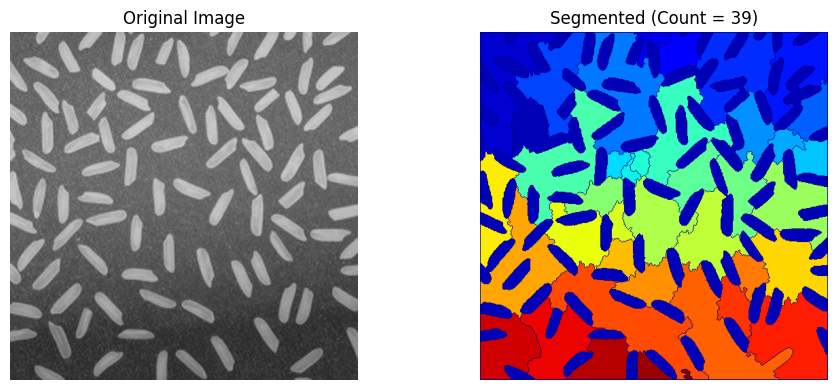

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Read Image
# --------------------------
# Load image
img = cv2.imread('rice.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# --------------------------
# Threshold (Otsu)
# --------------------------
# Automatically find threshold using Otsu's method
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert image so that rice grains become white (foreground)
thresh = cv2.bitwise_not(thresh)


# --------------------------
# Noise Removal (Morphology)
# --------------------------
# Create kernel
kernel = np.ones((3,3), np.uint8)

# Opening = erosion + dilation → removes small noise
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)


# --------------------------
# Distance Transform
# --------------------------
# Compute distance from background (used to separate objects)
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Threshold distance map to get sure foreground (center of objects)
_, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# --------------------------
# Background Detection
# --------------------------
# Dilate to get sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# --------------------------
# Unknown Region
# --------------------------
# Subtract foreground from background
unknown = cv2.subtract(sure_bg, sure_fg)


# --------------------------
# Marker Labelling
# --------------------------
# Label connected components (each object gets unique ID)
_, markers = cv2.connectedComponents(sure_fg)

# Increase marker values so background is not 0
markers = markers + 1

# Mark unknown regions as 0
markers[unknown == 255] = 0


# --------------------------
# Watershed Segmentation
# --------------------------
# Apply watershed algorithm
markers = cv2.watershed(img, markers)


# --------------------------
# Count Objects
# --------------------------
# Count unique labels (exclude background and boundary)
count = len(np.unique(markers)) - 2

print("Correct Rice Count:", count)


# --------------------------
# Display Results
# --------------------------
plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Segmented Image (each object labeled differently)
plt.subplot(1,2,2)
plt.imshow(markers, cmap='jet')
plt.title(f"Segmented (Count = {count})")
plt.axis('off')

plt.tight_layout()
plt.show()

### Lab 7: Write a Python program to read an image and perform convolution with 3X3 mask.

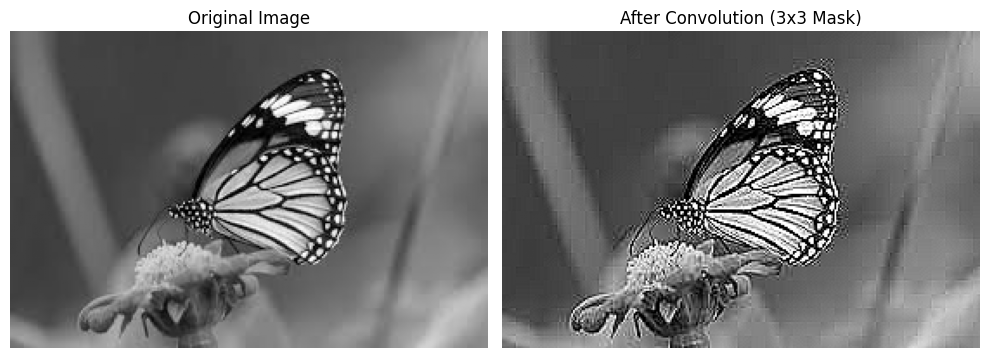

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Load Image ----------------
# Read image in grayscale mode
img = cv2.imread('download (1).jpg', 0)

# Check if image loaded successfully
if img is None:
    raise ValueError("Image not found!")


# ---------------- 3x3 Mask (Sharpening Kernel) ----------------
# Define a sharpening filter kernel
# Center value is high → enhances edges/details
kernel = np.array([[ 0, -1,  0],
                   [-1,  5, -1],
                   [ 0, -1,  0]])


# ---------------- Convolution ----------------
# Apply convolution using filter2D
# -1 means output image will have same depth as input
output = cv2.filter2D(img, -1, kernel)


# ---------------- Display Results ----------------
plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')   # Show grayscale image
plt.title("Original Image")
plt.axis('off')

# Convolved Image
plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("After Convolution (3x3 Mask)")
plt.axis('off')

# Adjust layout
plt.tight_layout()

# Show images
plt.show()

### Lab 8: Develop a MATLAB/Python program that performs a two-scale image decomposition using the wavelet transform, and generate plots to visualize the results.



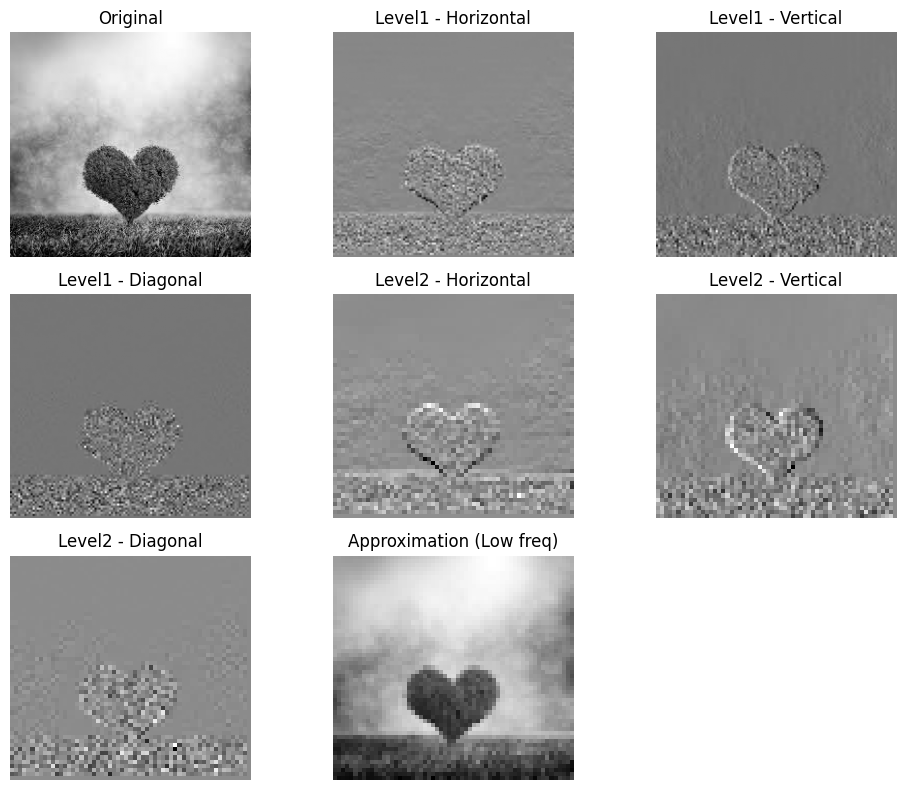

In [ ]:
import cv2
import pywt
import matplotlib.pyplot as plt

# ---------------- Load Image ----------------
# Read image in grayscale mode
img = cv2.imread('images.jpg', 0)


# ---------------- Wavelet Decomposition ----------------
# Perform 2-level 2D Discrete Wavelet Transform using Haar wavelet
coeffs = pywt.wavedec2(img, 'haar', level=2)

# Extract coefficients
# cA2 → Approximation (low frequency)
# cH → Horizontal detail, cV → Vertical detail, cD → Diagonal detail
cA2, (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs


# ---------------- Plotting Results ----------------
plt.figure(figsize=(10,8))

# -------- Original Image --------
plt.subplot(3,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')


# -------- Level 1 Details --------
# Horizontal edges (Level 1)
plt.subplot(3,3,2)
plt.imshow(cH1, cmap='gray')
plt.title("Level1 - Horizontal")
plt.axis('off')

# Vertical edges (Level 1)
plt.subplot(3,3,3)
plt.imshow(cV1, cmap='gray')
plt.title("Level1 - Vertical")
plt.axis('off')

# Diagonal edges (Level 1)
plt.subplot(3,3,4)
plt.imshow(cD1, cmap='gray')
plt.title("Level1 - Diagonal")
plt.axis('off')


# -------- Level 2 Details --------
# Coarser horizontal edges
plt.subplot(3,3,5)
plt.imshow(cH2, cmap='gray')
plt.title("Level2 - Horizontal")
plt.axis('off')

# Coarser vertical edges
plt.subplot(3,3,6)
plt.imshow(cV2, cmap='gray')
plt.title("Level2 - Vertical")
plt.axis('off')

# Coarser diagonal edges
plt.subplot(3,3,7)
plt.imshow(cD2, cmap='gray')
plt.title("Level2 - Diagonal")
plt.axis('off')


# -------- Approximation --------
# Low-frequency component (overall structure of image)
plt.subplot(3,3,8)
plt.imshow(cA2, cmap='gray')
plt.title("Approximation (Low freq)")
plt.axis('off')


# Adjust layout and display
plt.tight_layout()
plt.show()